In [1]:
from pathlib import Path
import matplotlib.pyplot as plt

from gsm_benchmarker.results_analyser import MultiVariantMultiModelResultsAnalyser
from gsm_benchmarker.answer_extractor import AnswerExtractor

plt.style.use('seaborn-v0_8-muted')
plt.style.use('seaborn-v0_8-darkgrid')

In [2]:
pp = Path("../../../../data/gsm-symbolic/outputs").resolve()
p_standard = pp / "mini_20x50x4__14_11/final"
p_sep = pp / 'separated_targets_20x50x4__26_11/final'
p_code = pp / 'mini_code_output_20x50__05_12/final'

In [3]:
mres_standard = MultiVariantMultiModelResultsAnalyser(p_standard)
mres_sep = MultiVariantMultiModelResultsAnalyser(p_sep)
mres_code = MultiVariantMultiModelResultsAnalyser(p_code)

Model: 100%|██████████| 20/20 [00:00<00:00, 99.77it/s] 
/home/guests2/dkd/code/gsm-symbolic-benchmarking/src/gsm_benchmarker/results_analyser/multi_model.py:65: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(full_data_dict.values(), keys=full_data_dict.keys(), names=['model', 'old_index'])
Model: 100%|██████████| 20/20 [00:00<00:00, 46.50it/s]
/home/guests2/dkd/code/gsm-symbolic-benchmarking/src/gsm_benchmarker/results_analyser/multi_model.py:65: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat op

In [4]:
failed_code = mres_code.variants['main'].get_failed_answer_cases()

In [5]:
def get_case(id: int, error_type: str, idx: int = 0, data = failed_code):
    return data[(data.id == id) & data.detected_result_pattern.apply(lambda s: s == error_type).to_numpy()].iloc[idx]

In [6]:
def print_qq(qq):
    print(f"MODEL: {qq['model']}")
    print(f"TEMPLATE ID: {qq['id']}")
    print("\nQUESTION")
    print(qq["question"])
    print(f"\nEXPECTED RESULT: {qq['numerical_result']}")
    print("\nANSWER")
    print(10*'-')
    t = AnswerExtractor.trim_response(qq["full_response"])
    print(t)
    if len(t) != len(qq['full_response']):
        print("...")
    print(10*'-')

    ret, e = AnswerExtractor.extract_answer_code(qq['full_response'])
    if ret is None:
        print("\nISSUE")
        print(e.name)

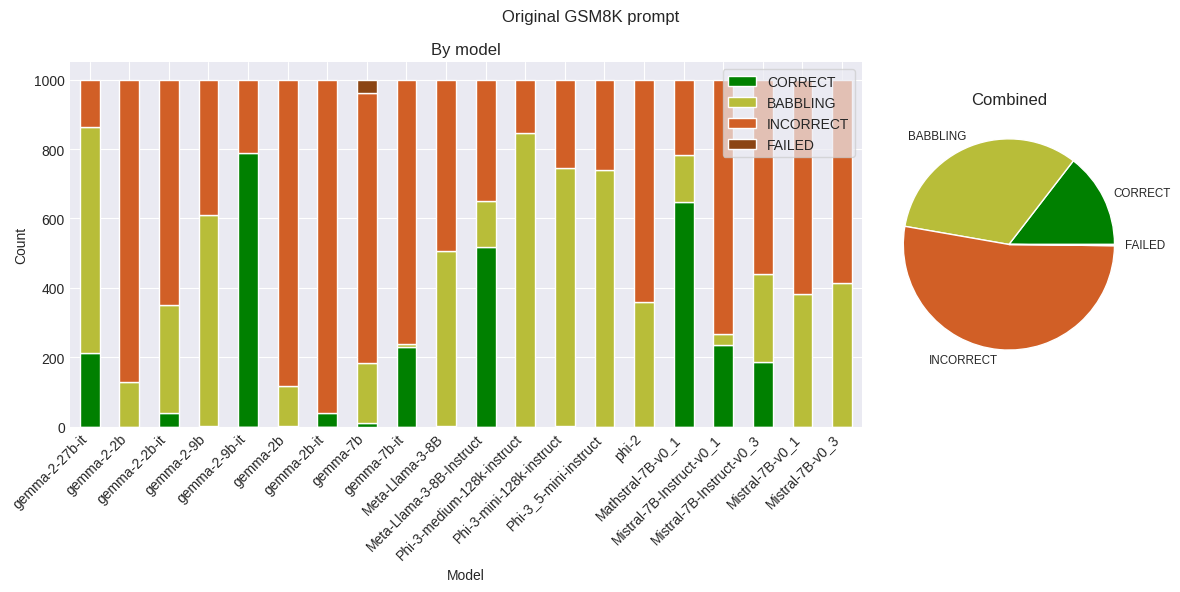

In [7]:
_ = mres_standard.variants['main'].plot_result_class_by_model("Original GSM8K prompt")

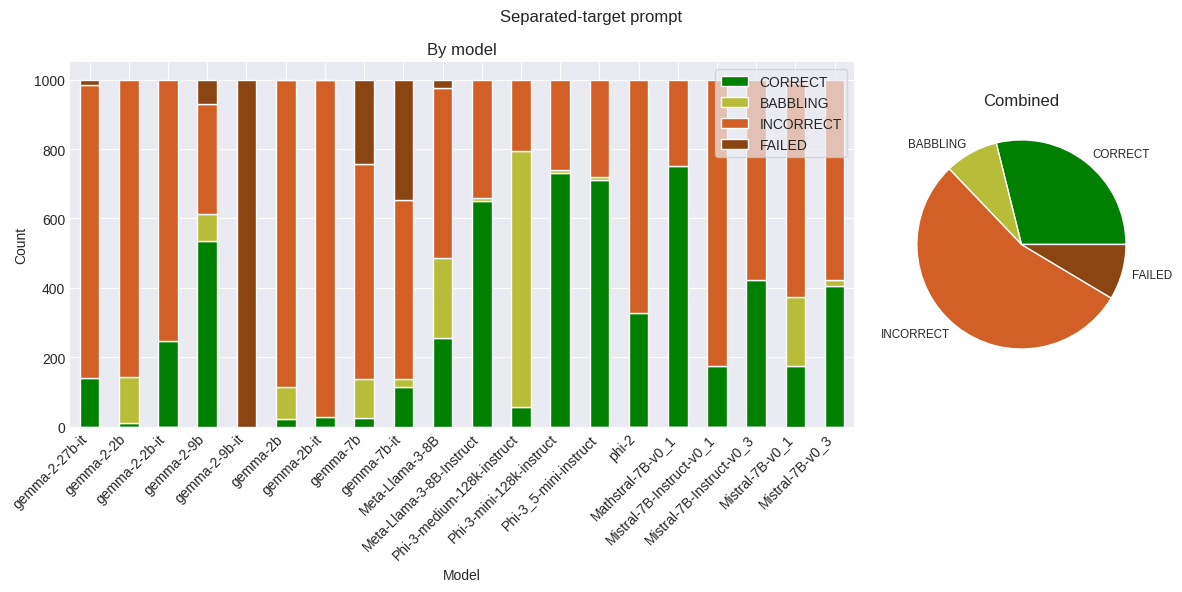

In [8]:
_ = mres_sep.variants['main'].plot_result_class_by_model(title='Separated-target prompt')

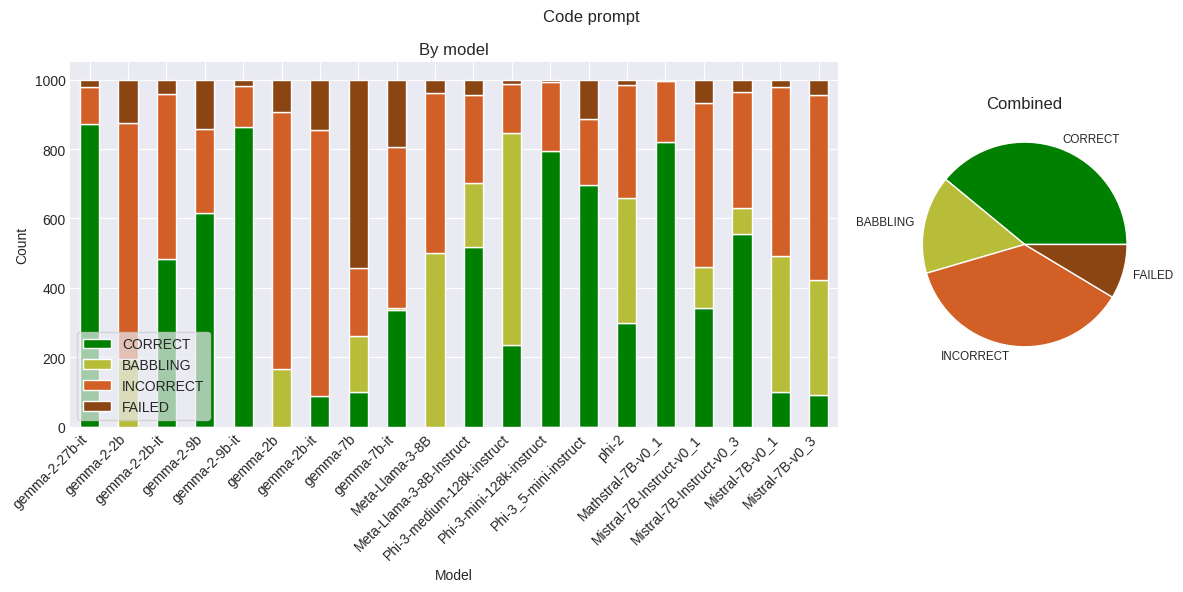

In [9]:
_ = mres_code.variants['main'].plot_result_class_by_model(title='Code prompt')

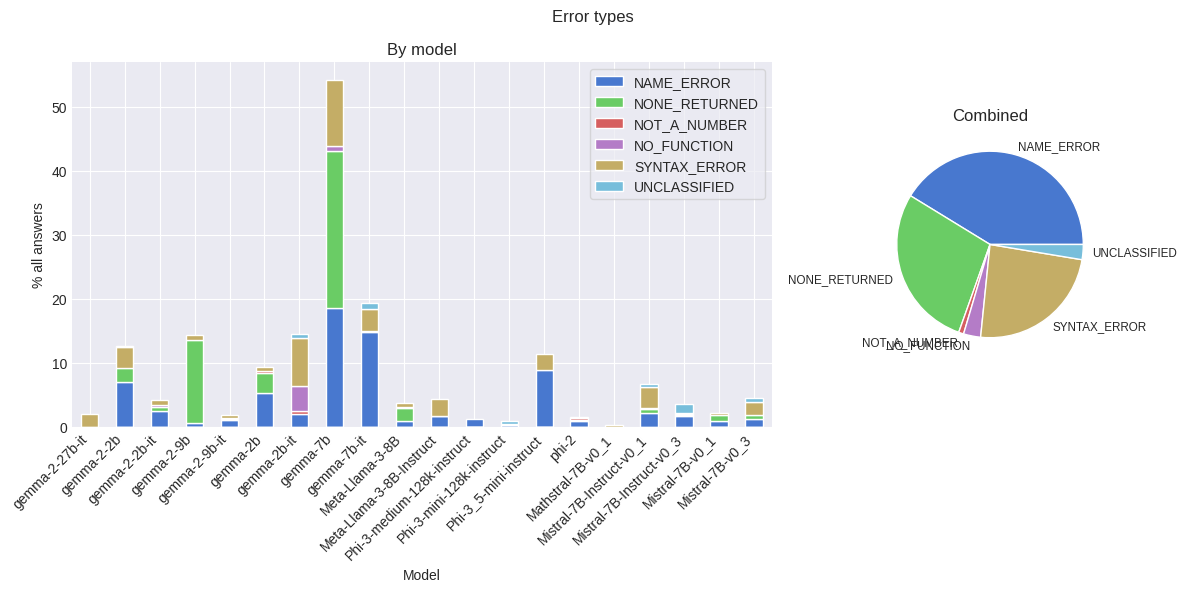

In [10]:
_ = mres_code.variants['main'].plot_error_types_by_model(percentage=True)


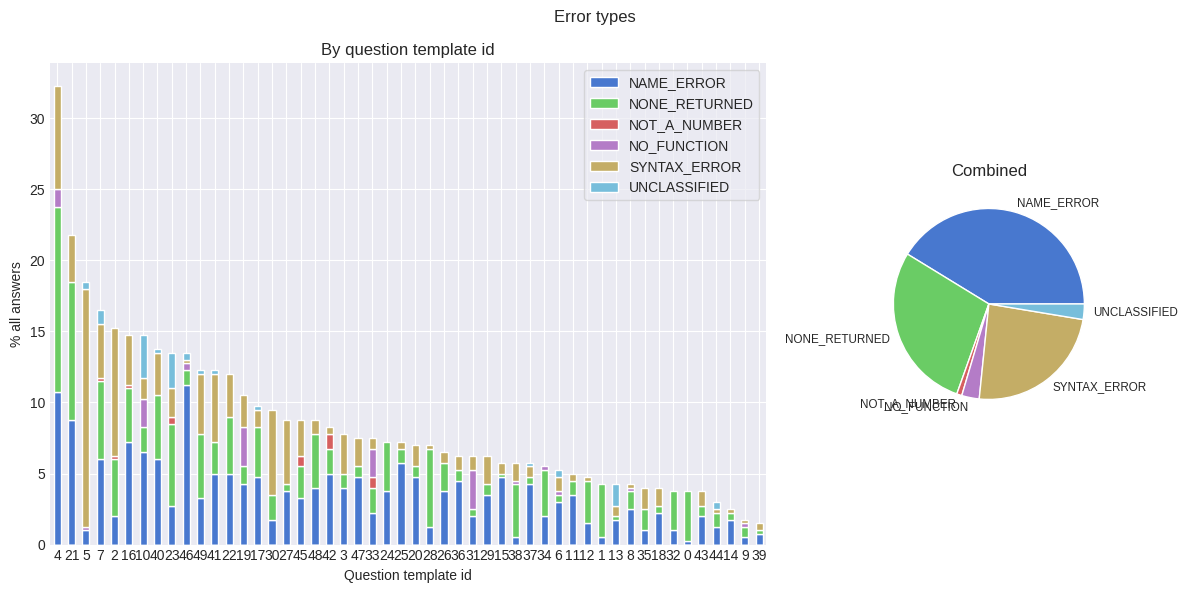

In [11]:
_ = mres_code.variants['main'].plot_error_types_by_question_id(percentage=True)

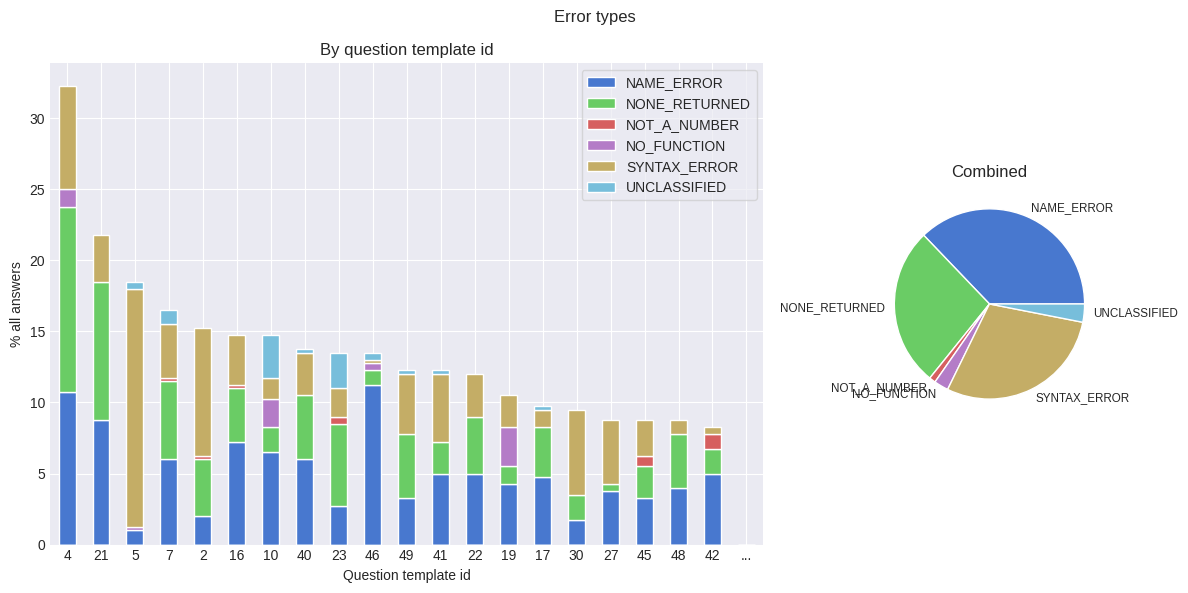

In [12]:
_ = mres_code.variants['main'].plot_error_types_by_question_id(max_questions=20, percentage=True)

In [13]:
print_qq(get_case(5, 'SYNTAX_ERROR', 2))

Extracted function definition has invalid syntax: invalid syntax (<string>, line 3)


MODEL: google_gemma-7b
TEMPLATE ID: 5

QUESTION
Yara makes tea using teaspoons of sugar and cups of water in the ratio of 29:5. If she used a total of 476 teaspoons of sugar and cups of water, calculate the number of teaspoonfuls of sugar she used.

EXPECTED RESULT: 406.0

ANSWER
----------
def solution():
    # given:
    ratio_of_sugar_to_water = 29:5  # ratio of sugar to water in the tea
    total_teaspoonfuls_of_sugar_and_water = 476  # total number of teaspoonfuls of sugar and water used

    # to find: number of teaspoonfuls of sugar used

    # solution:
    # first, calculate the number of teaspoonfuls of sugar in the ratio
    teaspoonfuls_of_sugar = ratio_of_sugar_to_water[0]
    # next, calculate the number of teaspoonful of water in the ratio
    teaspoonfuls_of_water = ratio_of_sugar_to_water[1]
    # next, calculate the sum of the number of teaspoonful of sugar and the number of teaspoonful of water
    teaspoonfuls_of_sugar_and_water = teaspoonfuls_of_sugar + teaspoonful

In [14]:
print_qq(get_case(41, 'SYNTAX_ERROR', 0))

Extracted function definition has invalid syntax: invalid syntax (<string>, line 5)


MODEL: meta-llama_Meta-Llama-3-8B
TEMPLATE ID: 41

QUESTION
A pyramid is made out of 9 white cubes, two times as many black cubes, and an unknown number of pink cubes. If there are 31 cubes in the pyramid in total, how many pink cubes are there?

EXPECTED RESULT: 4.0

ANSWER
----------
def solution():
    # given:
    white_cubes = 9  # number of white cubes in the pyramid
    black_cubes = 2 * white_cubes  # number of black cubes in the pyramid
    pink_cubes =?  # number of pink cubes in the pyramid
    total_cubes = 31  # total number of cubes in the pyramid

    # to find: number of pink cubes in the pyramid

    # solution:
    # first, calculate the total number of white and black cubes
    white_and_black_cubes = white_cubes + black_cubes
    # next, calculate the difference between the total number of cubes and the number of white and black cubes
    pink_cubes = total_cubes - white_and_black_cubes
    return pink_cubes



...
----------

ISSUE
SYNTAX_ERROR


In [15]:
print_qq(get_case(30, 'SYNTAX_ERROR', 3))

Extracted function definition has invalid syntax: invalid character '₺' (U+20BA) (<string>, line 3)


MODEL: google_gemma-7b-it
TEMPLATE ID: 30

QUESTION
Sophia has ₺102.5 and wants to buy 50 anchors from a bin at the home improvement store. Each anchor costs ₺0.17. How much money does Sophia have left after paying for the anchors?

EXPECTED RESULT: 94.0

ANSWER
----------
```python
def solution():
    # Given information
    sopiha_money = ₺102.5  # Sophia's total money
    anchors_cost = 50  # Number of anchors to buy
    anchor_cost = ₺0.17  # Cost of each anchor

    # Calculate the total cost of the anchors
    anchors_cost_total = anchors_cost * anchor_cost

    # Calculate the money left after paying for the anchors
    money_left = sophia_money - anchors_cost_total

    # Return the money left
    return int(money_left)
```

**Answer:**

```python
def solution():
    sopiha_money = ₺102.5
    anchors_cost = 50
    anchor_cost = ₺0.17

    anchors_cost_total = anchors_cost * anchor_cost
    money_left = sophia_money - anchors_cost_total

    return int(money_left)
```

**Note:**

In [16]:
print_qq(get_case(21, 'NONE_RETURNED', 5))

The function did not return any value


MODEL: google_gemma-7b
TEMPLATE ID: 21

QUESTION
Deshawn watches TV after he finishes his homework every night. On Sunday and Monday, he watched a 4-hour episode of his favorite show each night. On Tuesday, he watched a few episodes of a 15-minute show. On Wednesday, he finished homework early and watched a 4-hour episode and a 15-minute show. On Thursday, he got to stay up late, so he watched five 3-hour episodes. If he watched 28 hours of TV in all, how many 15-minute episodes did he watch on Tuesday?

EXPECTED RESULT: 3.0

ANSWER
----------
def solution():
    # given:
    tv_hours_on_sunday_and_monday = 4  # number of hours of TV Deshawn watched on Sunday and Monday
    tv_hours_on_tuesday = 15  # number of minutes of TV Deshawn watched on Tuesday
    
----------

ISSUE
NONE_RETURNED


In [17]:
print_qq(get_case(46, 'NAME_ERROR', 2))

NameError when running extracted function: name 'graduates' is not defined


MODEL: microsoft_Phi-3-medium-128k-instruct
TEMPLATE ID: 46

QUESTION
Greenville High School is holding graduation in their Convention Center this year which has space for 7900 people. After accounting for 1250 seats for graduates and 400 seats for faculty attending, how many tickets would each graduate receive to give to their friends and family if the tickets are split equally?

EXPECTED RESULT: 5.0

ANSWER
----------
def solution():
    # given:
    total_seats = 7900  # total number of seats in the Convention Center
    seats_for_graduates = 1250  # number of seats reserved for graduates
    seats_for_faculty = 400  # number of seats reserved for faculty

    # to find: number of tickets each graduate would receive to give to their friends and family

    # solution:
    # first, calculate the number of seats available for friends and family
    seats_for_friends_and_family = total_seats - seats_for_graduates - seats_for_faculty
    # next, calculate the number of tickets each grad

In [18]:
print_qq(get_case(4, 'NAME_ERROR', 2))

NameError when running extracted function: name 'total_popped_popcorn' is not defined


MODEL: google_gemma-2-9b-it
TEMPLATE ID: 4

QUESTION
Isabella is popping popcorn for a snack. As the pan of kernels heats up, the kernels start popping faster. 20 pop in the first 18 seconds of cooking, then 3 times that amount in the next 18 seconds. The kernels increase to 4 times the initial popping rate in the next 18 seconds, but in the final 18 seconds, the popping slows down to half the rate as the past 18 seconds. After Isabella takes the pan off the heat, a quarter of the number of kernels that popped in the final 18 seconds of cooking also pop from the residual heat. How many pieces of popcorn does Isabella have to eat?

EXPECTED RESULT: 210.0

ANSWER
----------
```python
def solution():
    #... your code here...
    return total_popped_popcorn
```




----------

ISSUE
NAME_ERROR


---

## Comparison to baseline (GSM8K) questions

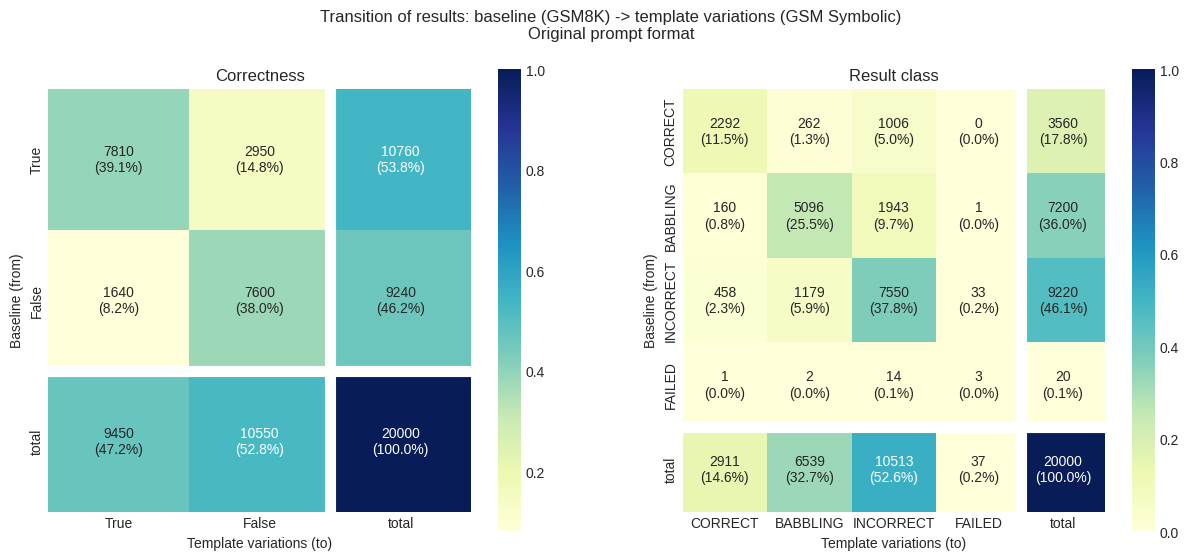

In [19]:
_ = mres_standard.plot_baseline_transition_matrices('main', 'Original prompt format')

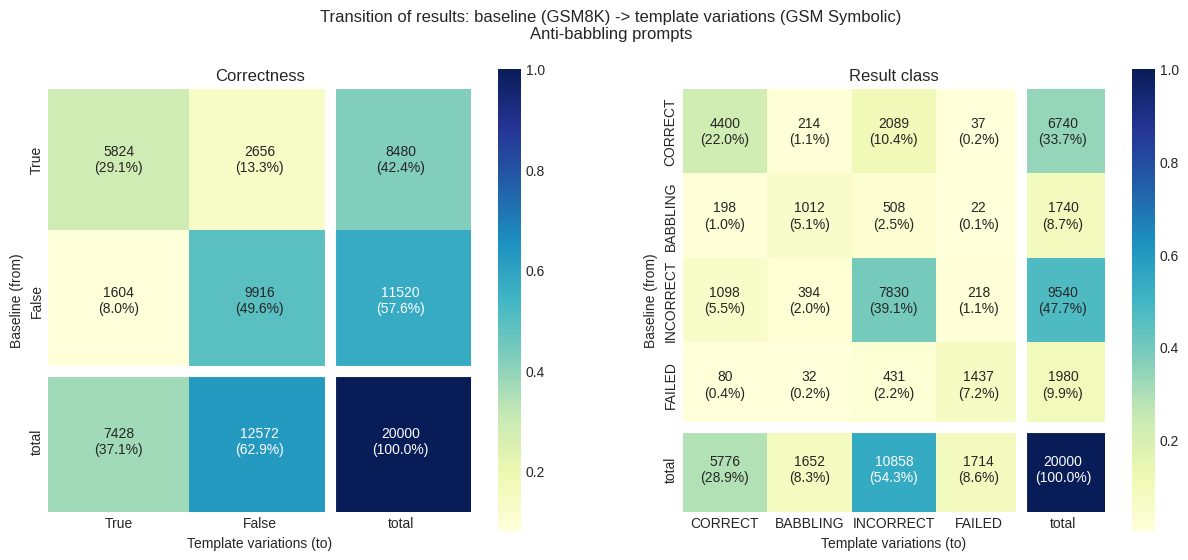

In [20]:
_ = mres_sep.plot_baseline_transition_matrices('main', 'Anti-babbling prompts')

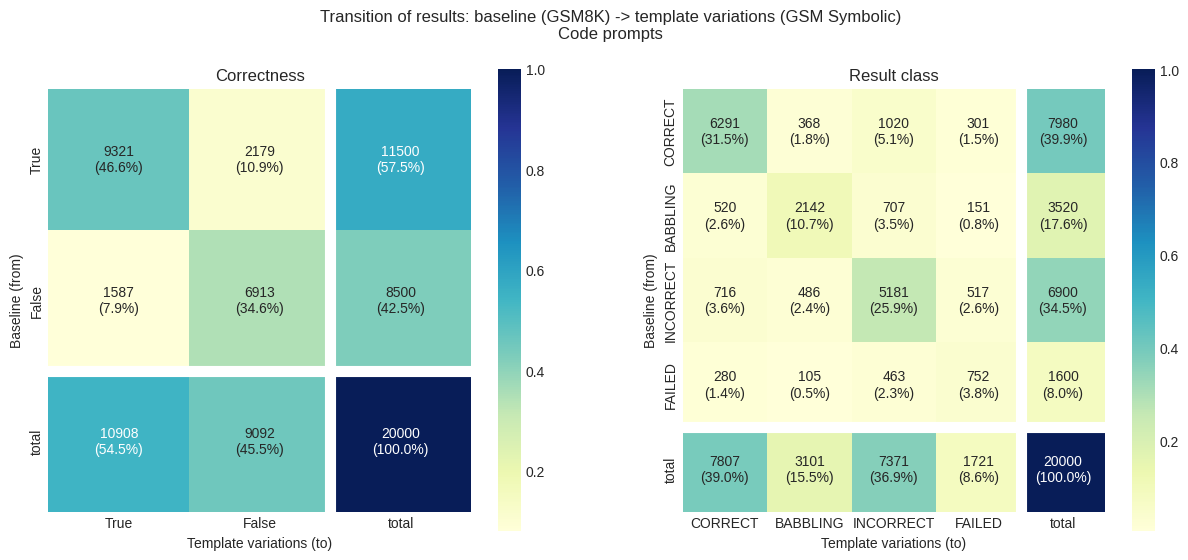

In [21]:
_ = mres_code.plot_baseline_transition_matrices('main', 'Code prompts')

In [22]:
mres_code.variants['GSM8K'].summary_data

,accuracy,std,strict_accuracy,strict_std
meta-llama_Meta-Llama-3-8B,0.44,NaN,0.00,NaN
microsoft_Phi-3-medium-128k-instruct,0.86,NaN,0.26,NaN
google_gemma-7b,0.36,NaN,0.12,NaN
google_gemma-2-9b-it,0.92,NaN,0.92,NaN
google_gemma-2-9b,0.58,NaN,0.58,NaN
microsoft_phi-2,0.68,NaN,0.34,NaN
meta-llama_Meta-Llama-3-8B-Instruct,0.70,NaN,0.44,NaN
mistralai_Mistral-7B-v0_1,0.56,NaN,0.04,NaN
google_gemma-7b-it,0.42,NaN,0.38,NaN
google_gemma-2b-it,0.12,NaN,0.12,NaN


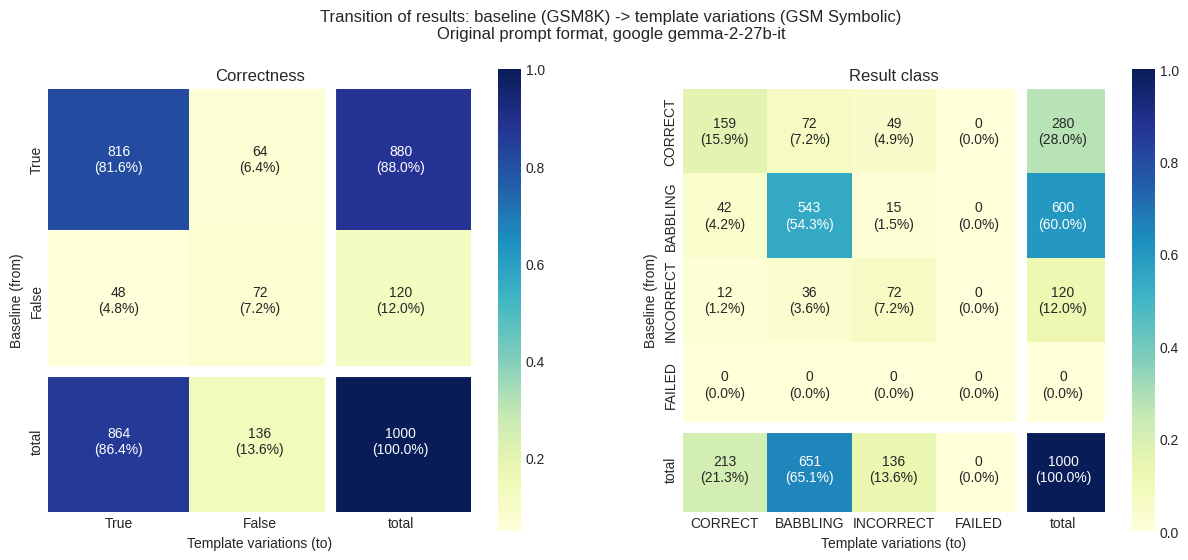

In [26]:
_ = mres_standard.plot_baseline_transition_matrices('main', model='google_gemma-2-27b-it', subtitle="Original prompt format")

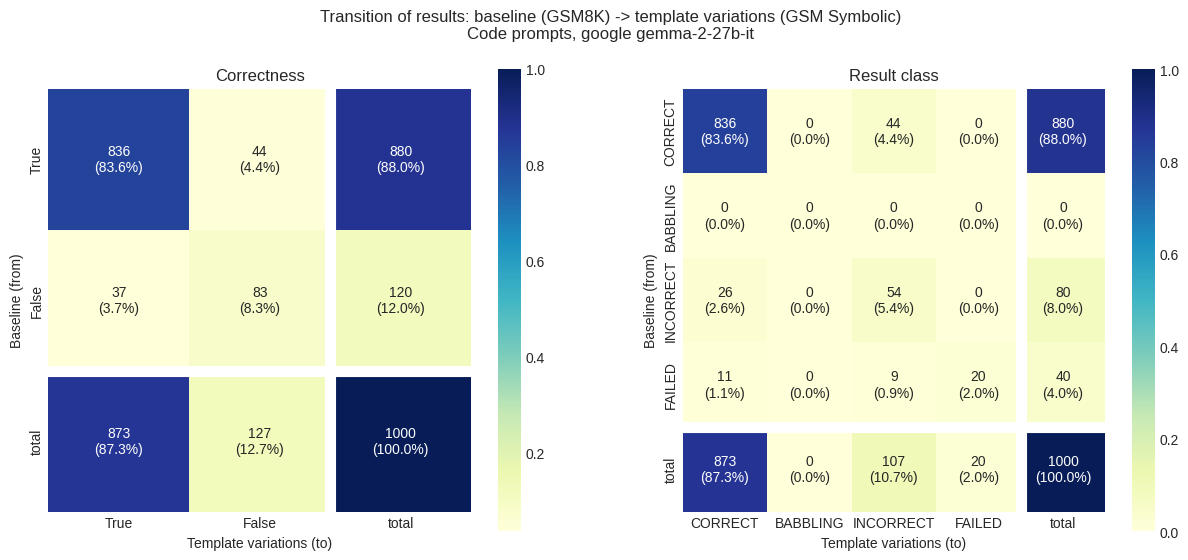

In [23]:
_ = mres_code.plot_baseline_transition_matrices('main', model='google_gemma-2-27b-it', subtitle="Code prompts")